In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from PIL import Image
import os

In [ ]:
img = Image.open("/content/1393368.jpg")
filename = name = os.path.splitext(filename)[0]

In [ ]:
image = np.array(img)
image

array([[[150, 111,  96],
        [154, 104,  93],
        [162,  80,  82],
        ...,
        [151,  62,  90],
        [135,  94, 102],
        [130, 104, 107]],

       [[151, 102,  87],
        [156,  94,  83],
        [169,  68,  76],
        ...,
        [161,  52,  84],
        [143,  79,  95],
        [136,  90, 101]],

       [[156,  74,  62],
        [166,  64,  62],
        [185,  37,  59],
        ...,
        [190,  24,  70],
        [162,  41,  72],
        [149,  49,  77]],

       ...,

       [[ 99,   0,  29],
        [100,   1,  30],
        [101,   2,  31],
        ...,
        [ 97,   3,  30],
        [ 96,   2,  28],
        [ 96,   0,  27]],

       [[ 99,   0,  29],
        [ 99,   0,  29],
        [101,   2,  31],
        ...,
        [ 97,   3,  30],
        [ 97,   1,  28],
        [ 99,   1,  26]],

       [[ 99,   0,  29],
        [100,   1,  30],
        [100,   4,  32],
        ...,
        [ 97,   3,  29],
        [ 99,   1,  26],
        [ 99,   0,  23]]

In [ ]:
data = image.astype(float) / 255.0
data = data.reshape(image.shape[0] * image.shape[1], 3)
data.shape

(8294400, 3)

In [ ]:
data

array([[0.58823529, 0.43529412, 0.37647059],
       [0.60392157, 0.40784314, 0.36470588],
       [0.63529412, 0.31372549, 0.32156863],
       ...,
       [0.38039216, 0.01176471, 0.11372549],
       [0.38823529, 0.00392157, 0.10196078],
       [0.38823529, 0.        , 0.09019608]])

In [ ]:
def plot_pixels(data, title, colors=None, N=10000):
  rng = np.random.RandomState(0)
  i = rng.permutation(data.shape[0])[:N]
  sample = data[i]

  # Determine the colors for the scatter plot
  if colors is None:
    plot_colors = sample
  else:
    plot_colors = colors[i]

  R, G, B = sample.T

  fig, ax = plt.subplots(1, 2, figsize=(16, 6))
  ax[0].scatter(R, G, color=plot_colors)
  ax[0].set(xlabel="Red", ylabel="Green", xlim=(0, 1), ylim=(0, 1))
  ax[1].scatter(R, B, color=plot_colors)
  ax[1].set(xlabel="Red", ylabel="Blue", xlim=(0, 1), ylim=(0, 1))

  fig.suptitle(title, fontsize=20)

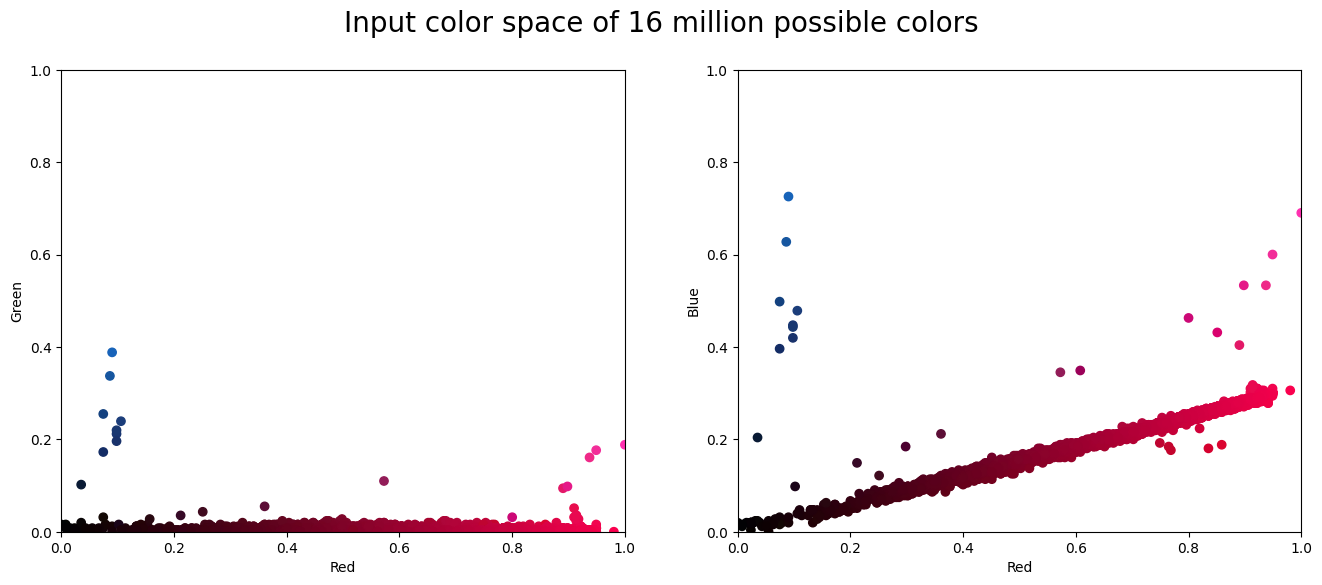

In [ ]:
plot_pixels(data, title="Input color space of 16 million possible colors")

In [ ]:
number_of_colors = 16

kmeans = MiniBatchKMeans(number_of_colors)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

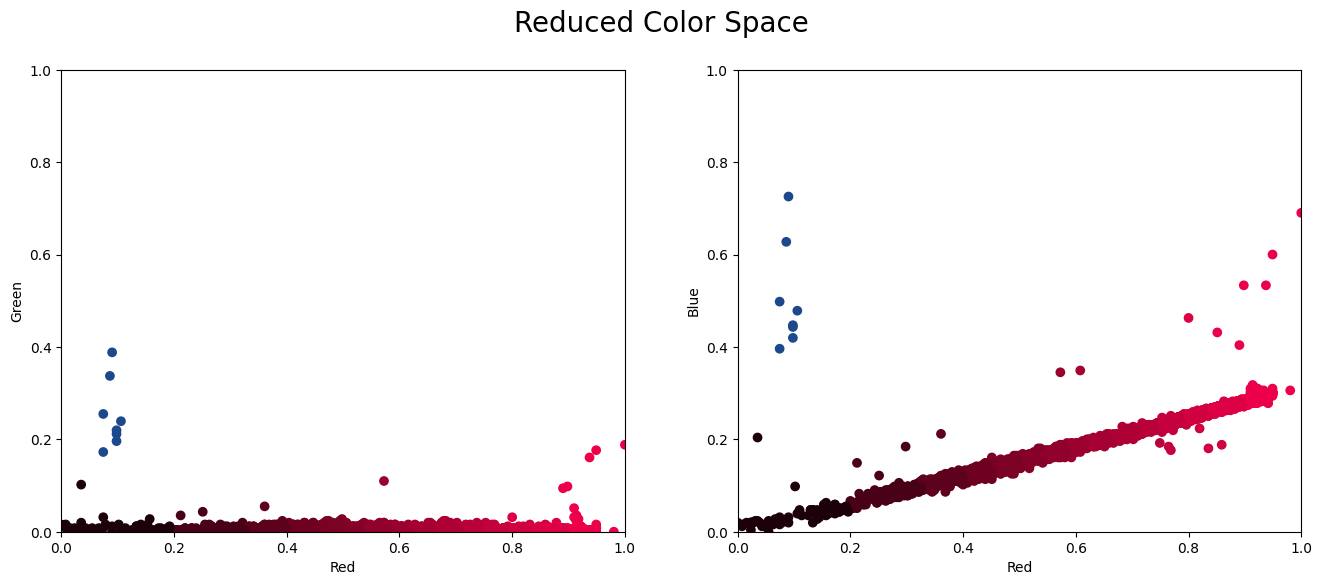

In [ ]:
plot_pixels(data, colors=new_colors, title="Reduced Color Space")

In [ ]:
image_recolored = new_colors.reshape(image.shape)

output = Image.fromarray((image_recolored * 255).astype(np.uint8))
output.save(f"{filename}_quantized.png")